In [1]:
%load_ext autoreload
%autoreload 2

In [19]:
import sys
from pathlib import Path
import torch
import torch.nn as nn

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

from model.transformer_class import RNABaselineModel
from model.utils import masked_mse_loss, center_coords
from model.dataset_loader import RNADataset, RNATestDataset, rna_collate_fn, rna_test_collate_fn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import plotly.graph_objects as go


plt.style.use("default")
plt.rcParams["figure.figsize"] = (15,6)
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

# Loading data

In [3]:
train_sequence = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/train_sequences.csv"
)
train_labels = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/train_labels.csv"
)
validation_sequence = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/validation_sequences.csv"
)
validation_labels = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/validation_labels.csv"
)

test_sequence = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/test_sequences.csv"
)



C:\Users\Admin\AppData\Local\Temp\ipykernel_16408\77482081.py:4: DtypeWarning: Columns (0: chain) have mixed types. Specify dtype option on import or set low_memory=False.
  train_labels = pd.read_csv(


In [4]:
train_sequence.head()

,target_id,sequence,temporal_cutoff,description,stoichiometry,all_sequences,ligand_ids,ligand_SMILES
0,4TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1978-04-12,FURTHER REFINEMENT OF THE STRUCTURE OF YEAST T...,A:1,>4TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
1,6TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1979-01-16,CRYSTAL STRUCTURE OF YEAST PHENYLALANINE T-RNA...,A:1,>6TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
2,1TRA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-07-14,RESTRAINED REFINEMENT OF THE MONOCLINIC FORM O...,A:1,>1TRA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
3,1TN2,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-10-24,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN2_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN
4,1TN1,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1987-01-15,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN1_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN


In [5]:
train_labels.head()

,ID,resname,resid,x_1,y_1,z_1,chain,copy
0,157D_1,C,1,4.843,-5.640,13.265,A,1
1,157D_2,G,2,3.385,-7.613,8.267,A,1
2,157D_3,C,3,2.158,-6.751,2.949,A,1
3,157D_4,G,4,2.669,-4.843,-1.773,A,1
4,157D_5,A,5,3.509,0.239,-4.045,A,1


In [6]:
print("number of unique target IDs which are pdb_id_chain_id", train_sequence["target_id"].nunique())

number of unique target IDs which are pdb_id_chain_id 5716


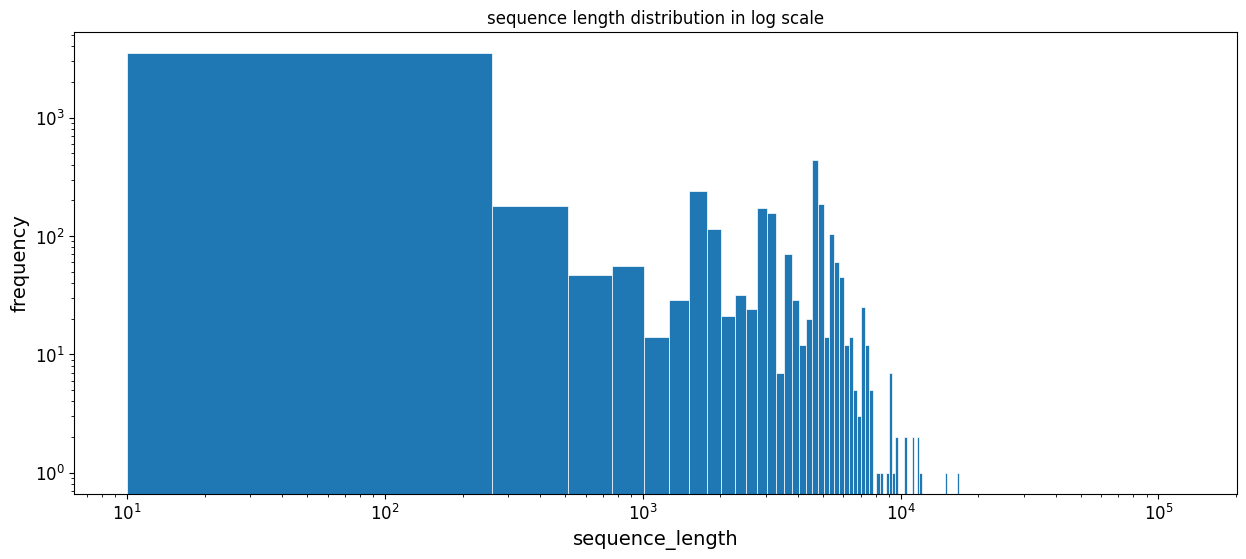

In [7]:
# distribution of sequence lengths:

train_sequence["len_sequence"] = train_sequence["sequence"].str.len()

fig, ax = plt.subplots()

ax.hist(train_sequence["len_sequence"], bins=500, linewidth=0.5, edgecolor="white")
ax.set_yscale('log', base=10)
ax.set_xscale('log', base=10)
plt.xlabel("sequence_length")
plt.ylabel("frequency")
plt.title("sequence length distribution in log scale")
plt.show()


In [8]:
train_labels[["split_ID", "suffix"]] = train_labels["ID"].str.split('_', expand=True)

In [9]:
# plotting some target examples
unique_ids = train_labels["split_ID"].unique()
for target_id in unique_ids[:1]:
    # target_id = train_labels["ID"].iloc[i].split("_")[0]
    sub = train_labels[train_labels["ID"].str.startswith(target_id)]

    x = sub["x_1"].values
    y = sub["y_1"].values
    z = sub["z_1"].values


    fig = go.Figure(
        data=[go.Scatter3d(
            x=x, y=y, z=z,
            mode="lines+markers",
            marker=dict(size=3),
            line=dict(width=2)
        )]
    )

    fig.update_layout(
        title=f"RNA structure: {target_id}",
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z"
        )
    )

    fig.show()



In [10]:

lengths = train_sequence["sequence"].str.len()

print("sequence length percentiles:", np.percentile(lengths, [50, 75, 90, 95, 99]))

sequence length percentiles: [  94.5  2583.75 4751.   5348.   7230.6 ]


In [11]:
# Reducing long sequences examples for initial model run

# filtered_train_sequence = train_sequence[train_sequence["sequence"].str.len() <2500]

valid_targets = set(
    train_sequence.loc[train_sequence.len_sequence < 2000, "target_id"]
)

train_sequences = train_sequence[
    train_sequence.target_id.isin(valid_targets)
]

train_labels = train_labels[
    train_labels.split_ID.isin(valid_targets)
]

# Modeling

In [12]:
from torch.utils.data import DataLoader

dataset = RNADataset(train_sequences, train_labels)

# Checking correct dataset creation: sequence should be of shape (L,), and each nucleotide should have 3 coordinates, which makes shape (L,3)
seq, coords = dataset[0]

print(seq.shape)     # (L,)
print(coords.shape)  # (L, 3)

torch.Size([76])
torch.Size([76, 3])


In [13]:
dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=rna_collate_fn
)

In [14]:
model = RNABaselineModel()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

In [15]:
batch = next(iter(dataloader))

tokens = batch["tokens"]
coords = batch["coords"]
mask = batch["mask"]

print(tokens.shape)
print(coords.shape)
print(mask.shape)

pred = model(tokens)
loss = masked_mse_loss(pred, coords, mask)

loss.backward()
optimizer.step()
optimizer.zero_grad()

print("Loss:", loss.item())


torch.Size([4, 1632])
torch.Size([4, 1632, 3])
torch.Size([4, 1632])
Loss: 133358.59375


In [16]:
model.train()
loss_vs = []
for step, batch in enumerate(dataloader):
    tokens = batch["tokens"]
    coords = batch["coords"]
    mask = batch["mask"]

    pred = model(tokens)

    coords_centered = center_coords(coords, mask)
    pred_centered   = center_coords(pred, mask)

    loss = masked_mse_loss(pred_centered, coords_centered, mask)
    loss_vs.append(loss.item())

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if step % 10 == 0:
        print(f"Step {step} | Loss {loss.item():.2f}")

    if step == 500:
        break


Step 0 | Loss 5159.12
Step 10 | Loss 6286.21
Step 20 | Loss 5696.22
Step 30 | Loss 8787.89
Step 40 | Loss 32495.26
Step 50 | Loss 1767.21
Step 60 | Loss 5290.48
Step 70 | Loss 13366.38
Step 80 | Loss 12811.71
Step 90 | Loss 1773.90
Step 100 | Loss 3608.41
Step 110 | Loss 4238.19
Step 120 | Loss 13461.82
Step 130 | Loss 5184.67
Step 140 | Loss 2730.58
Step 150 | Loss 3554.24
Step 160 | Loss 323.49
Step 170 | Loss 11594.24
Step 180 | Loss 982.09
Step 190 | Loss 7256.17
Step 200 | Loss 1737.58
Step 210 | Loss 10322.72
Step 220 | Loss 1095.66
Step 230 | Loss 15774.30
Step 240 | Loss 4963.02
Step 250 | Loss 1719.31
Step 260 | Loss 6710.14
Step 270 | Loss 4154.95
Step 280 | Loss 10140.82
Step 290 | Loss 285.51
Step 300 | Loss 1113.78
Step 310 | Loss 3063.15
Step 320 | Loss 4114.49
Step 330 | Loss 9909.26
Step 340 | Loss 11436.07
Step 350 | Loss 5143.67
Step 360 | Loss 1091.27
Step 370 | Loss 702.99
Step 380 | Loss 2164.79
Step 390 | Loss 8450.04
Step 400 | Loss 2312.94
Step 410 | Loss 4216.5

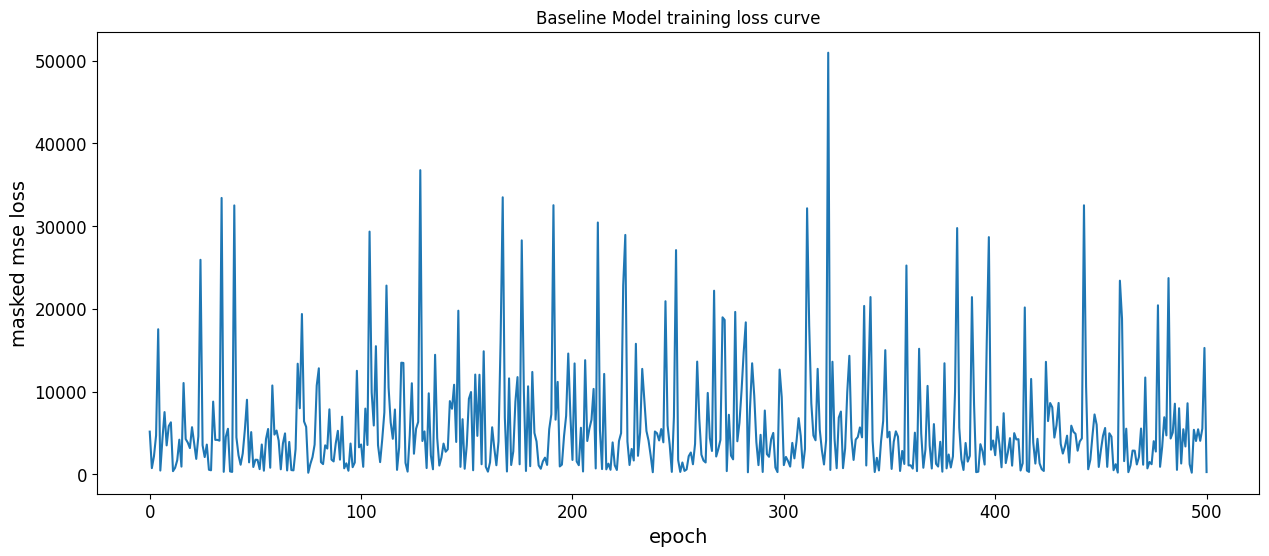

In [17]:
plt.plot(loss_vs)
plt.xlabel("epoch")
plt.ylabel("masked mse loss")
plt.title("Baseline Model training loss curve")
plt.show()

In [20]:
from torch.utils.data import DataLoader

test_dataset = RNATestDataset(test_sequence)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,          # IMPORTANT for submission simplicity
    shuffle=False,
    collate_fn=rna_test_collate_fn
)

In [21]:
# shapes
batch = next(iter(test_loader))

print(batch["tokens"].shape)   # (1, L)
print(batch["mask"].shape)     # (1, L)
print(batch["meta"])

torch.Size([1, 30])
torch.Size([1, 30])
[{'target_id': '8ZNQ', 'length': 30}]


# Naive Inference 

In [26]:
model.eval()

all_predictions = []

with torch.no_grad():
    # disables dropout (if any)
    # disables gradient tracking
    # saves memory

    for batch in test_loader:
        tokens = batch["tokens"]       # (1, L)
        mask = batch["mask"]           # (1, L)
        meta = batch["meta"][0]        # dict

        pred = model(tokens)           # (1, L, 3)
        pred = pred.squeeze(0)         # (L, 3)

        L = meta["length"]

        all_predictions.append({
            "target_id": meta["target_id"],
            "coords": pred[:L].cpu().numpy()  # (L, 3)
        })

In [ ]:
# Create submission
submission_rows = []

for item in all_predictions:
    target_id = item["target_id"]
    coords = item["coords"]      # (L, 3)

    # Get original sequence from test_sequences_df
    seq = test_sequence.loc[
        test_sequence["target_id"] == target_id, "sequence"
    ].values[0]

    for i, nucleotide in enumerate(seq):
        row = {
            "ID": f"{target_id}_{i+1}",
            "resname": nucleotide,
            "resid": i + 1,
        }

        # repeat same coords for x_1..x_5
        for k in range(1, 6):
            row[f"x_{k}"] = float(coords[i, 0])
            row[f"y_{k}"] = float(coords[i, 1])
            row[f"z_{k}"] = float(coords[i, 2])

        submission_rows.append(row)

submission_df = pd.DataFrame(submission_rows)

submission_df.to_csv("submission.csv", index=False)

In [28]:
submission_df

,ID,resname,resid,x_1,y_1,z_1,x_2,y_2,z_2,x_3,y_3,z_3,x_4,y_4,z_4,x_5,y_5,z_5
0,8ZNQ_1,A,1,-0.064621,-0.083871,0.055520,-0.064621,-0.083871,0.055520,-0.064621,-0.083871,0.055520,-0.064621,-0.083871,0.055520,-0.064621,-0.083871,0.055520
1,8ZNQ_2,C,2,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297
2,8ZNQ_3,C,3,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297
3,8ZNQ_4,G,4,-0.188467,0.445127,0.476367,-0.188467,0.445127,0.476367,-0.188467,0.445127,0.476367,-0.188467,0.445127,0.476367,-0.188467,0.445127,0.476367
4,8ZNQ_5,U,5,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9757,9ZCC_1456,C,1456,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297
9758,9ZCC_1457,C,1457,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297,-1.270448,-1.196355,-0.923297
9759,9ZCC_1458,U,1458,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758
9760,9ZCC_1459,U,1459,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758,-0.463006,-0.294700,-0.065758
